# AI / ML Job Market Analysis

**Goal:** Understand the AI/ML job market — which roles are most common, what they pay, how experience and work mode affect salary, and which skills employers ask for most.

**Dataset:** *`AI_ML_Job_Market_Analysis.xlsx`*, one row per job posting (title, company, location, experience, employment type, work mode, education, salary in LPA, skills, posting date).



## 1. Loading and cleaning

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation,PillowWriter
from IPython.display import Image, display


DATA_PATH = r"C:\Users\DELL\Documents\AI_ML_Job_Market_Analysis.xlsx"   
df=pd.read_excel(DATA_PATH,index_col="JobID")
pd.set_option('display.width',2000)

print(df)
print(df.size)
print(df.columns)
print(df.info())
print(df.head(5))
print(df.tail(5))
print("Missing values per column:\n", df.isna().sum())
print("Duplicate rows:", df.reset_index().duplicated().sum())
df = df.reset_index().drop_duplicates().set_index("JobID")
df["PostingDate"] = pd.to_datetime(df["PostingDate"], errors="coerce")
df["Education"] = df["Education"].fillna("Not specified")
print("Rows after cleaning:", len(df))


                          JobTitle      Company   Location ExperienceLevel  ExperienceYears EmploymentType WorkMode   Education  Salary_LPA                                             Skills PostingDate
JobID                                                                                                                                                                                                     
JOB0654                AI Engineer     TechNova    Chennai       Mid-level                4      Full-time   Remote  Bachelor's       12.11  Machine Learning, AWS, LLMs, NumPy, Spark, Sci...  2025-01-01
JOB0323             Data Scientist     TechNova       Pune          Senior                8      Full-time  On-site    Master's       21.16  SQL, Machine Learning, AWS, Statistics, NLP, P...  2025-01-03
JOB0149               Data Analyst  FutureStack   Gurugram       Mid-level                5      Part-time  On-site         NaN       11.35   Matplotlib, Generative AI, SQL, Git, AWS, Pyth

## 2. Job market overview





In [3]:
print("Unique Jobs : " , df['JobTitle'].unique())
print("Top 10 job titles : \n", df['JobTitle'].value_counts().head(10))
frq_jobs=df.groupby('ExperienceLevel')
pd.set_option('display.max_rows',1008)
job_L=frq_jobs['JobTitle'].value_counts().reset_index()#jobL=job at expereience level
job_L.columns = ["JobLevel", "JobTitle", "Jobavailable"]
job_avail=job_L.groupby("JobLevel")
print("Jobs available for each experience level : " ,job_avail["Jobavailable"].sum())
print("Most common employment type : " , df['EmploymentType'].value_counts().idxmax())
counts=(df["WorkMode"])=="Remote"
check=counts.value_counts(normalize=True)*100
print("Percentage of jobs which are remote : " ,check[True],"%")

Unique Jobs :  <StringArray>
['AI Engineer', 'Data Scientist', 'Data Analyst', 'MLOps Engineer', 'Deep Learning Engineer', 'Machine Learning Engineer', 'Generative AI Engineer', 'AI Research Scientist', 'Computer Vision Engineer', 'NLP Engineer']
Length: 10, dtype: str
Top 10 job titles : 
 JobTitle
Machine Learning Engineer    118
AI Engineer                  110
AI Research Scientist        107
NLP Engineer                 107
Generative AI Engineer       100
Computer Vision Engineer      96
Data Analyst                  94
MLOps Engineer                94
Deep Learning Engineer        91
Data Scientist                83
Name: count, dtype: int64
Jobs available for each experience level :  JobLevel
Entry-level    289
Lead            69
Mid-level      405
Senior         237
Name: Jobavailable, dtype: int64
Most common employment type :  Full-time
Percentage of jobs which are remote :  30.9 %


## 3. Salary analysis

In [4]:
print("Median salary (LPA): " ,df['Salary_LPA'].median())
print("Average salary (LPA): " , df['Salary_LPA'].mean())
print("Maximum salary (LPA): " , df["Salary_LPA"].max())
print("Minimum salary (LPA): " , df["Salary_LPA"].min())
salary=df.groupby('JobTitle')
print("Average salary(LPA) for each jobtitle: " , salary['Salary_LPA'].mean())
median_by_title = salary["Salary_LPA"].median().sort_values(ascending=False)
print("Highest median salary (LPA) by jobtitle : \n", median_by_title.head(3))
print("Job title with the highest median salary :", median_by_title.idxmax(), "-", median_by_title.max())
low_cut, high_cut = np.percentile(df["Salary_LPA"].dropna(), [100/3, 200/3])
print("Salary cut-offs (LPA):", round(low_cut, 2), "and", round(high_cut, 2))
df["salcategory"]=np.where(df["Salary_LPA"].isna(),"salary not listed",np.where(df["Salary_LPA"]<=low_cut,"Low salary",np.where(df["Salary_LPA"]<=high_cut ,"medium salary","high salary")))
print("Count of salcategory : " ,df['salcategory'].value_counts())
df["expcategory"]=np.where(df["ExperienceYears"]<=2,"0-2 years",np.where(df["ExperienceYears"]<=5,"3-5 years","6+ years"))
print("Percentage of jobs requiring experience : ",df["expcategory"].value_counts(normalize=True)*100,"%")


Median salary (LPA):  10.855
Average salary (LPA):  11.957
Maximum salary (LPA):  29.81
Minimum salary (LPA):  2.5
Average salary(LPA) for each jobtitle:  JobTitle
AI Engineer                  12.316545
AI Research Scientist        12.704327
Computer Vision Engineer     10.566452
Data Analyst                 11.321505
Data Scientist               12.981646
Deep Learning Engineer       13.026966
Generative AI Engineer       11.110206
MLOps Engineer               11.537849
Machine Learning Engineer    12.285000
NLP Engineer                 11.749906
Name: Salary_LPA, dtype: float64
Highest median salary (LPA) by jobtitle : 
 JobTitle
Data Scientist            12.110
Deep Learning Engineer    11.620
AI Engineer               11.555
Name: Salary_LPA, dtype: float64
Job title with the highest median salary : Data Scientist - 12.11
Salary cut-offs (LPA): 8.36 and 13.84
Count of salcategory :  salcategory
high salary          327
Low salary           327
medium salary        326
salary not li

## 4. Skills analysis

In [5]:
skills = df["Skills"].dropna()      

skills_count = (
    skills
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts(normalize=True)*100
)
print("Top ten frequently requested skills in AI/ML job (% of all skill mentions) : \n" ,skills_count.nlargest(10))


posting_pct = skills.str.split(",").explode().str.strip().value_counts() / len(skills) * 100
print("\nTop ten skills as % of job postings : \n", posting_pct.head(10).round(1))


has_python = skills.str.contains(r"\bPython\b")
has_sql = skills.str.contains(r"\bSQL\b")
print("\nPython requirement : " , has_python.mean()*100,"%")
print("SQL requirement : " , has_sql.mean()*100,"%")


python_sql_percent = has_sql[has_python].mean() * 100
print("Of jobs requiring Python, also requiring SQL:", python_sql_percent, "%")
print("(for reference - Python AND SQL out of ALL jobs:", (has_python & has_sql).mean() * 100, "%)")


skills_by_job = df.groupby("JobTitle")      
ml_skills = (
    skills_by_job["Skills"].get_group("Machine Learning Engineer")
    .dropna().str.split(",").explode().str.strip().value_counts()
)
print("\nMost appeared skills in ML Engineer Job: \n" , ml_skills.head(10))


Top ten frequently requested skills in AI/ML job (% of all skill mentions) : 
 Skills
Python              7.397445
Machine Learning    7.363820
Git                 7.347007
SQL                 7.229321
PyTorch             4.757902
Generative AI       4.472091
NLP                 4.337592
Deep Learning       4.236718
LLMs                4.102219
GCP                 3.850034
Name: proportion, dtype: float64

Top ten skills as % of job postings : 
 Skills
Python              44.4
Machine Learning    44.2
Git                 44.1
SQL                 43.4
PyTorch             28.6
Generative AI       26.9
NLP                 26.1
Deep Learning       25.5
LLMs                24.6
GCP                 23.1
Name: count, dtype: float64

Python requirement :  44.44444444444444 %
SQL requirement :  43.43434343434344 %
Of jobs requiring Python, also requiring SQL: 42.72727272727273 %
(for reference - Python AND SQL out of ALL jobs: 18.98989898989899 %)

Most appeared skills in ML Engineer Job: 
 Ski

## 5. Visualizations

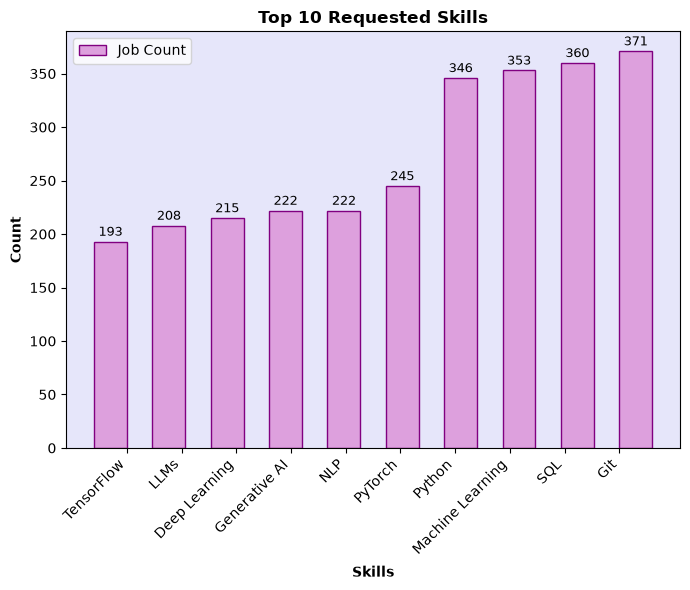

In [6]:
skillcount=df["Skills"].dropna().str.split(",").explode().value_counts().nlargest(10).reset_index()
skillcount.columns=["skills","counts"]
Skill = skillcount["skills"].iloc[::-1]
Count = skillcount["counts"].iloc[::-1]
plt.style.use('seaborn-v0_8-deep')
x = np.arange(len(Skill))

shift = np.linspace(-0.3, 0.3, len(Skill))

plt.figure(figsize=(7, 6))

bar=plt.bar(x + shift, Count, width=0.6,
        color="plum",
        edgecolor="purple")

plt.gca().set_facecolor("lavender")

plt.xticks(x, Skill, rotation=45, ha="right")

plt.xlabel("Skills",fontweight="bold")
plt.ylabel("Count",fontweight="bold")
plt.gca().bar_label(bar,padding=2, fontsize=9)
plt.title("Top 10 Requested Skills",fontweight="bold")

plt.legend(["Job Count"])

plt.tight_layout()
plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_1400\1510156525.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


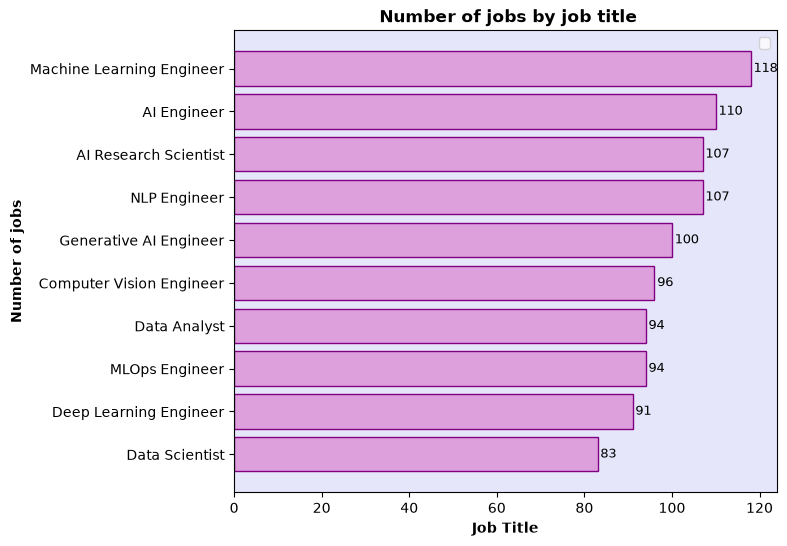

In [7]:
jobs=df["JobTitle"].value_counts().reset_index()
jobs.columns=["jobs","counts"]
Job=jobs["jobs"].iloc[::-1]
Counts=jobs["counts"].iloc[::-1]
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(7, 6))
bar=plt.barh(Job,Counts,color="plum",edgecolor="purple")
plt.gca().bar_label(bar, padding=2, fontsize=9)
plt.gca().set_facecolor("lavender")
plt.xlabel("Job Title",fontweight="bold")
plt.ylabel("Number of jobs",fontweight="bold")
plt.title(" Number of jobs by job title",fontweight="bold")
plt.legend()
plt.show()

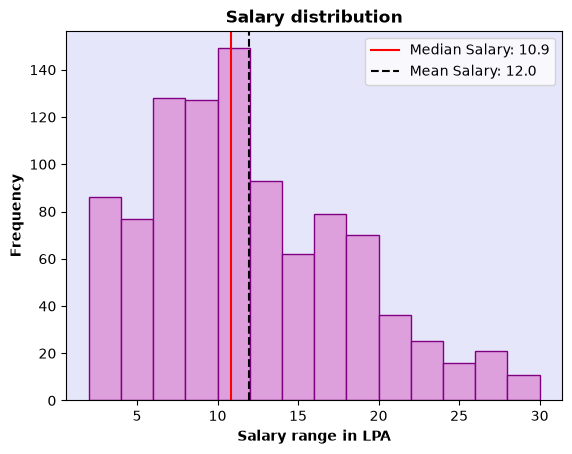

In [8]:

salary=df["Salary_LPA"]
bins=np.arange(np.floor(salary.min()/2)*2, salary.max()+2, 2)
plt.style.use("seaborn-v0_8-deep")
plt.hist(salary,bins=bins,color="plum",edgecolor="purple")
plt.gca().set_facecolor("lavender")
plt.xlabel("Salary range in LPA",fontweight="bold")
plt.ylabel("Frequency",fontweight="bold")
plt.title("Salary distribution",fontweight="bold")
mediansal=salary.median()
plt.axvline(mediansal,color="red",label=f"Median Salary: {mediansal:.1f}")
plt.axvline(salary.mean(),color="black",linestyle="--",label=f"Mean Salary: {salary.mean():.1f}")   # ADDED
plt.legend()
plt.show()

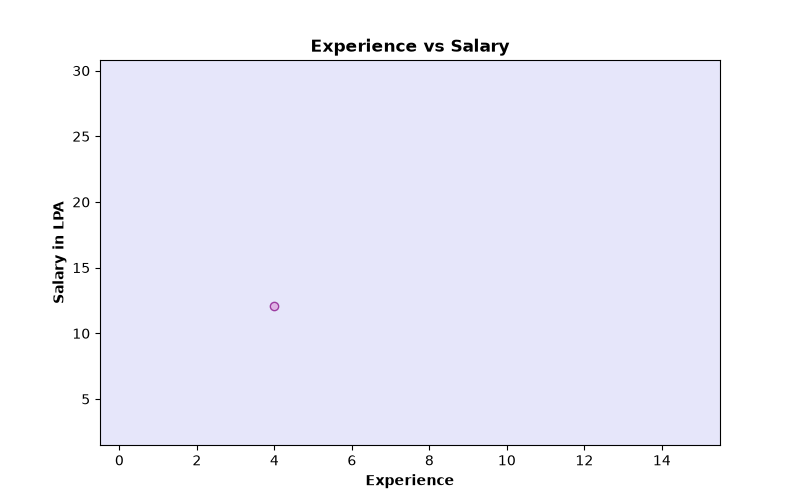

In [9]:
data = df[["ExperienceYears", "Salary_LPA"]].dropna()

x = data["ExperienceYears"].to_numpy()
y = data["Salary_LPA"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    [], [],
    color="plum",
    edgecolor="purple",
    alpha=0.7
)
plt.gca().set_facecolor("lavender")

ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(y.min() - 1, y.max() + 1)

ax.set_xlabel("Experience", fontweight="bold")
ax.set_ylabel("Salary in LPA", fontweight="bold")
ax.set_title("Experience vs Salary", fontweight="bold")

# 100 animation frames instead of thousands
frames = np.linspace(1, len(x), 100).astype(int)

def update(frame):
    scatter.set_offsets(
        np.column_stack((x[:frame], y[:frame]))
    )
    return scatter,

animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=80,
    repeat=True
)

animation.save(
    "experience_vs_salary.gif",
    writer=PillowWriter(fps=12)
)

plt.close(fig)

display(Image(filename="experience_vs_salary.gif"))

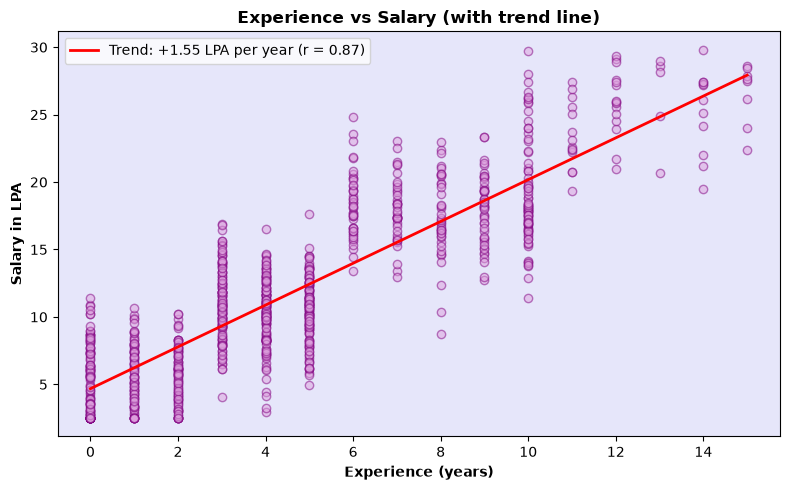

In [10]:
exp_data = df[["ExperienceYears", "Salary_LPA"]].dropna()
exp_x = exp_data["ExperienceYears"].to_numpy()
sal_y = exp_data["Salary_LPA"].to_numpy()

slope, intercept = np.polyfit(exp_x, sal_y, 1)
r = np.corrcoef(exp_x, sal_y)[0, 1]

plt.figure(figsize=(8, 5))
plt.scatter(exp_x, sal_y, color="plum", edgecolor="purple", alpha=0.5)
xs = np.linspace(exp_x.min(), exp_x.max(), 100)
plt.plot(xs, slope * xs + intercept, color="red", linewidth=2,
         label=f"Trend: +{slope:.2f} LPA per year (r = {r:.2f})")
plt.gca().set_facecolor("lavender")
plt.xlabel("Experience (years)", fontweight="bold")
plt.ylabel("Salary in LPA", fontweight="bold")
plt.title("Experience vs Salary (with trend line)", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

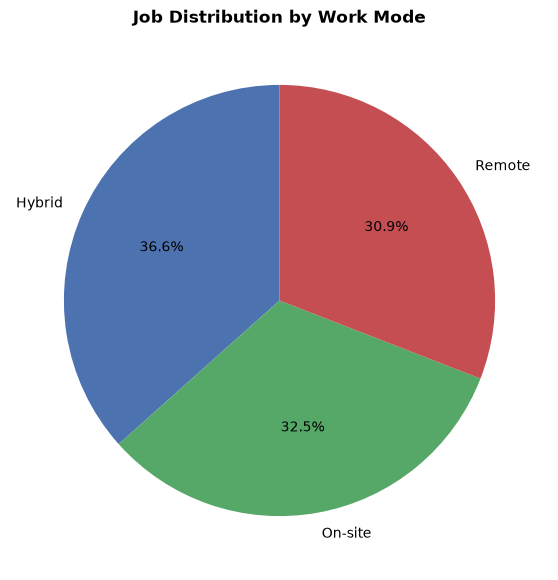

In [11]:
workmode = df["WorkMode"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    workmode.values,
    labels=workmode.index,
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Job Distribution by Work Mode", fontweight="bold")

plt.show()

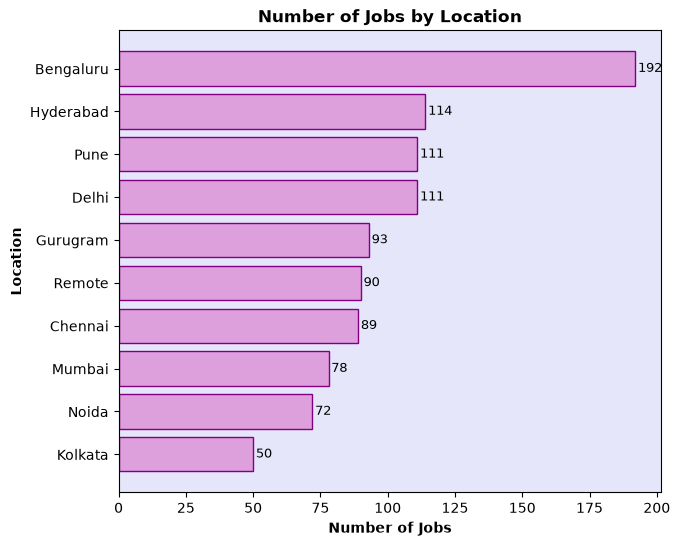

In [12]:
y = df["Location"].value_counts().reset_index()
y.columns = ["Location", "JobCount"]
y = y.iloc[::-1]
plt.figure(figsize=(7, 6))   
bar=plt.barh(y["Location"], y["JobCount"],color="plum",edgecolor="purple")
plt.gca().bar_label(bar,padding=2,fontsize=9)
plt.gca().set_facecolor("lavender")
plt.xlabel("Number of Jobs",fontweight="bold")
plt.ylabel("Location",fontweight="bold")
plt.title("Number of Jobs by Location",fontweight="bold")
plt.show()

(20 postings with no salary listed are excluded from this chart)


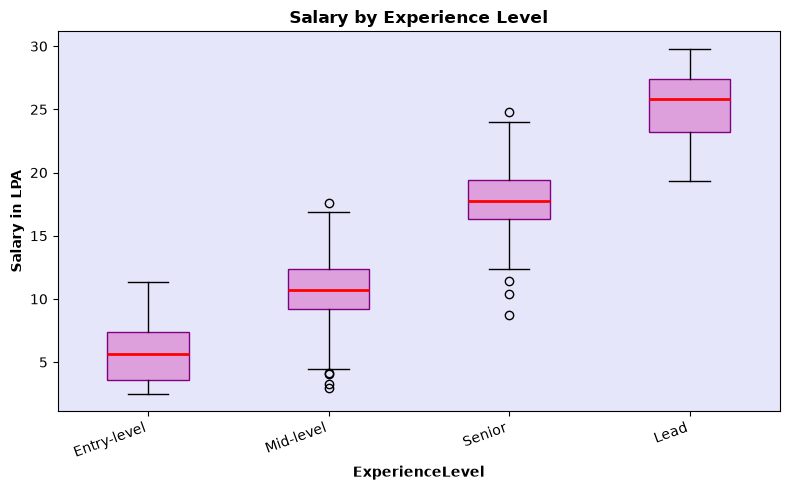

,median,mean,postings
ExperienceLevel,,,
Entry-level,5.66,5.64,281
Mid-level,10.73,10.64,396
Senior,17.73,17.83,234
Lead,25.85,25.30,69


In [48]:
def boxplot_by(col, order=None, title=None):
    cats = order or list(df.groupby(col)["Salary_LPA"].median().sort_values().index)
    cats = [c for c in cats if c in set(df[col])]
    data = [df.loc[df[col] == c, "Salary_LPA"].dropna() for c in cats]
    print(f"({df['Salary_LPA'].isna().sum()} postings with no salary listed are excluded from this chart)")

    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot(data, patch_artist=True, medianprops={"color": "red", "linewidth": 2})
    for box in bp["boxes"]:
        box.set(facecolor="plum", edgecolor="purple")
    ax.set_xticks(range(1, len(cats) + 1))
    ax.set_xticklabels(cats, rotation=20, ha="right")
    ax.set_facecolor("lavender")
    ax.set_xlabel(col, fontweight="bold")
    ax.set_ylabel("Salary in LPA", fontweight="bold")
    ax.set_title(title or f"Salary by {col}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return (df.groupby(col)["Salary_LPA"].agg(median="median", mean="mean", postings="count")
              .round(2).loc[cats])


display(boxplot_by("ExperienceLevel", ["Entry-level", "Mid-level", "Senior", "Lead"], "Salary by Experience Level"))

(20 postings with no salary listed are excluded from this chart)


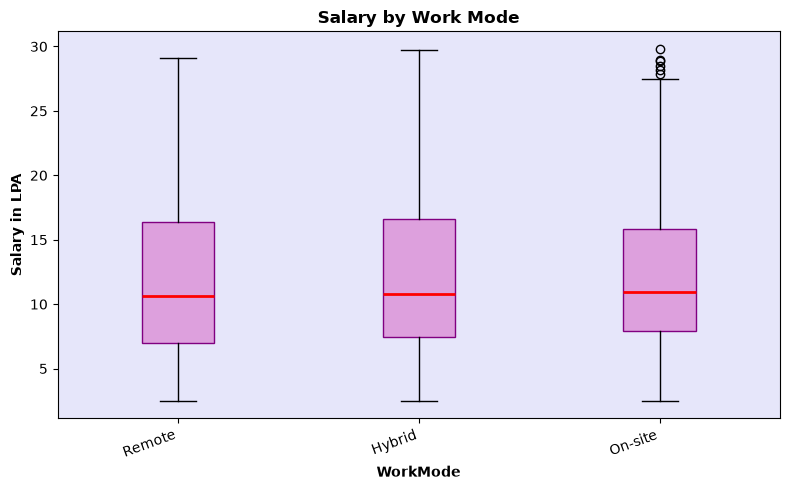

,median,mean,postings
WorkMode,,,
Remote,10.66,11.65,305
Hybrid,10.81,12.01,355
On-site,10.97,12.20,320


(20 postings with no salary listed are excluded from this chart)


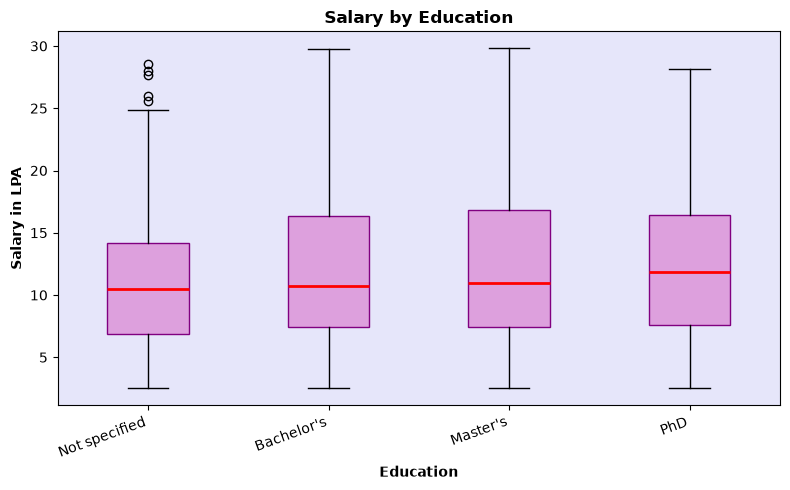

,median,mean,postings
Education,,,
Not specified,10.48,11.24,117
Bachelor's,10.76,11.79,439
Master's,10.93,12.33,334
PhD,11.84,12.33,90


In [49]:
display(boxplot_by("WorkMode", title="Salary by Work Mode"))
display(boxplot_by("Education", title="Salary by Education"))

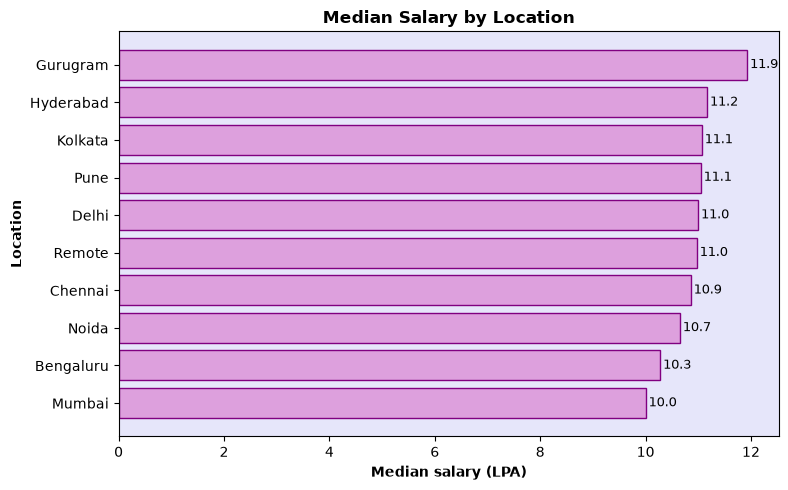

In [53]:
loc_sal = (df.groupby("Location")["Salary_LPA"]
             .agg(median="median", postings="count")
             .query("postings >= 20")
             .sort_values("median"))

plt.figure(figsize=(8, 5))
bars = plt.barh(loc_sal.index, loc_sal["median"], color="plum", edgecolor="purple")
plt.gca().bar_label(bars, fmt="%.1f", padding=2, fontsize=9)
plt.gca().set_facecolor("lavender")
plt.xlabel("Median salary (LPA)", fontweight="bold")
plt.ylabel("Location", fontweight="bold")
plt.title("Median Salary by Location", fontweight="bold")
plt.tight_layout()
plt.show()

,skill,postings,median_with,median_without,premium
8,LLMs,244,11.56,10.66,0.90
20,Matplotlib,191,11.38,10.78,0.60
16,Scikit-learn,203,11.31,10.73,0.58
22,Pandas,179,11.23,10.80,0.43
2,Git,437,11.03,10.66,0.37
0,Python,440,10.94,10.76,0.18
19,NumPy,194,11.00,10.82,0.18
7,Deep Learning,252,10.93,10.82,0.11
14,Kubernetes,211,10.93,10.84,0.09
3,SQL,430,10.84,10.81,0.03


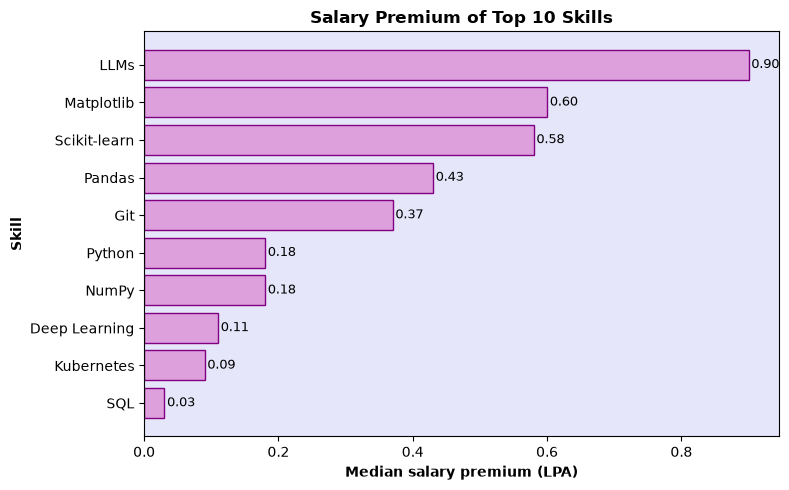

In [52]:
sk = df.dropna(subset=["Skills"]).copy()
sk["SkillList"] = sk["Skills"].str.split(",").apply(lambda lst: [s.strip() for s in lst])
skill_counts = sk["SkillList"].explode().value_counts()

rows = []
for skill, n in skill_counts.items():
    if n < 30:                                    # skip rare skills
        continue
    m = sk["SkillList"].apply(lambda lst: skill in lst)
    rows.append({"skill": skill, "postings": n,
                 "median_with": sk.loc[m, "Salary_LPA"].median(),
                 "median_without": sk.loc[~m, "Salary_LPA"].median()})

premium = pd.DataFrame(rows)
premium["premium"] = (premium["median_with"] - premium["median_without"]).round(2)
premium = premium.sort_values("premium", ascending=False)
display(premium.head(10).round(2))

top = premium.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
bars = plt.barh(top["skill"], top["premium"], color="plum", edgecolor="purple")
plt.gca().bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
plt.gca().set_facecolor("lavender")
plt.xlabel("Median salary premium (LPA)", fontweight="bold")
plt.ylabel("Skill", fontweight="bold")
plt.title("Salary Premium of Top 10 Skills", fontweight="bold")
plt.tight_layout()
plt.show()

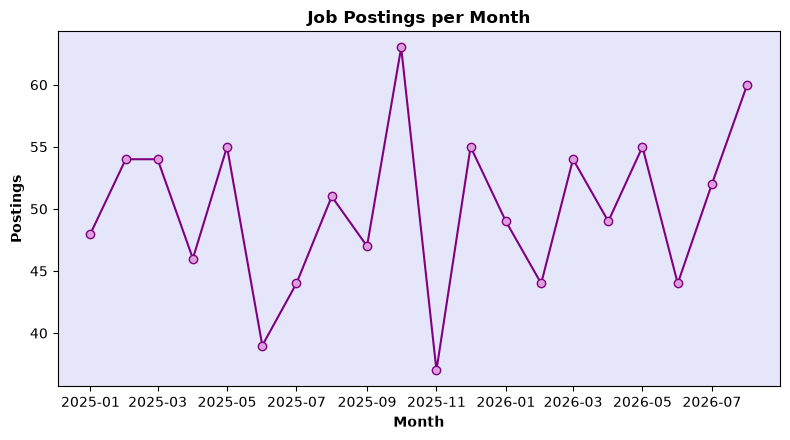

In [51]:
monthly = (df.dropna(subset=["PostingDate"])
             .set_index("PostingDate")
             .resample("MS").size())

plt.figure(figsize=(8, 4.5))
plt.plot(monthly.index, monthly.values, marker="o", color="purple", markerfacecolor="plum")
plt.gca().set_facecolor("lavender")
plt.xlabel("Month", fontweight="bold")
plt.ylabel("Postings", fontweight="bold")
plt.title("Job Postings per Month", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Key takeaways

In [50]:
sal_all = df["Salary_LPA"]
title_med = df.groupby("JobTitle")["Salary_LPA"].median()
lvl_med = df.groupby("ExperienceLevel")["Salary_LPA"].median()
mode_med = df.groupby("WorkMode")["Salary_LPA"].median()
loc_med = df.groupby("Location")["Salary_LPA"].agg(["median", "count"]).query("count >= 20")["median"]
best_skill = premium.iloc[0]

print(f"- Dataset: {len(df):,} postings, {df['JobTitle'].nunique()} job titles, {df['Location'].nunique()} locations.")
print(f"- Most common experience level: {df['ExperienceLevel'].value_counts().idxmax()}; "
      f"most common employment type: {df['EmploymentType'].value_counts().idxmax()}; "
      f"{(df['WorkMode'] == 'Remote').mean() * 100:.1f}% of jobs are remote.")
print(f"- Median salary is {sal_all.median():.1f} LPA (mean {sal_all.mean():.1f}, range {sal_all.min():.1f}-{sal_all.max():.1f}).")
print(f"- Highest median pay by title: {title_med.idxmax()} ({title_med.max():.1f} LPA).")
print(f"- Each extra year of experience is associated with about +{slope:.2f} LPA (correlation r = {r:.2f}).")
print(f"- Highest median salary by level: {lvl_med.idxmax()} ({lvl_med.max():.1f} LPA); lowest: {lvl_med.idxmin()} ({lvl_med.min():.1f} LPA).")
print(f"- Work mode with the highest median salary: {mode_med.idxmax()} ({mode_med.max():.1f} LPA).")
print(f"- City with the highest median salary (20+ postings): {loc_med.idxmax()} ({loc_med.max():.1f} LPA).")
print(f"- Most requested skills: {', '.join(posting_pct.index[:4])}; "
      f"{python_sql_percent:.0f}% of Python jobs also want SQL.")
print(f"- Biggest median salary premium: {best_skill['skill']} (+{best_skill['premium']:.2f} LPA).")

NameError: name 'premium' is not defined